In [39]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from google.colab import drive
import pandas as pd

drive.mount("/content/drive")
df = pd.read_excel("/content/drive/MyDrive/Folds5x2_pp.xlsx")
dataset = pd.read_excel('/content/drive/MyDrive/Folds5x2_pp.xlsx')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
dataset.rename(columns={'AT': 'Average Temperature', 'V': 'Exhaust Vacuum','AP': 'Ambient Pressure',
                   'RH': 'Relative Humidity ','PE': 'Net Hourly Electrical Energy Output'}, inplace=True)
dataset.head()

,Average Temperature,Exhaust Vacuum,Ambient Pressure,Relative Humidity,Net Hourly Electrical Energy Output
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [42]:
dataset.shape

(9568, 5)

In [43]:
#Mengecek kelengkapan value
dataset.isnull().sum()

,0
Average Temperature,0
Exhaust Vacuum,0
Ambient Pressure,0
Relative Humidity,0
Net Hourly Electrical Energy Output,0


In [44]:
dataset.describe()

,Average Temperature,Exhaust Vacuum,Ambient Pressure,Relative Humidity,Net Hourly Electrical Energy Output
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [45]:
dataset.corr()

,Average Temperature,Exhaust Vacuum,Ambient Pressure,Relative Humidity,Net Hourly Electrical Energy Output
Average Temperature,1.000000,0.844107,-0.507549,-0.542535,-0.948128
Exhaust Vacuum,0.844107,1.000000,-0.413502,-0.312187,-0.869780
Ambient Pressure,-0.507549,-0.413502,1.000000,0.099574,0.518429
Relative Humidity,-0.542535,-0.312187,0.099574,1.000000,0.389794
Net Hourly Electrical Energy Output,-0.948128,-0.869780,0.518429,0.389794,1.000000


In [46]:
dataset.corr()["Net Hourly Electrical Energy Output"].sort_values(ascending=False)

,Net Hourly Electrical Energy Output
Net Hourly Electrical Energy Output,1.000000
Ambient Pressure,0.518429
Relative Humidity,0.389794
Exhaust Vacuum,-0.869780
Average Temperature,-0.948128


### Visualisasi perbandingan pada dataset

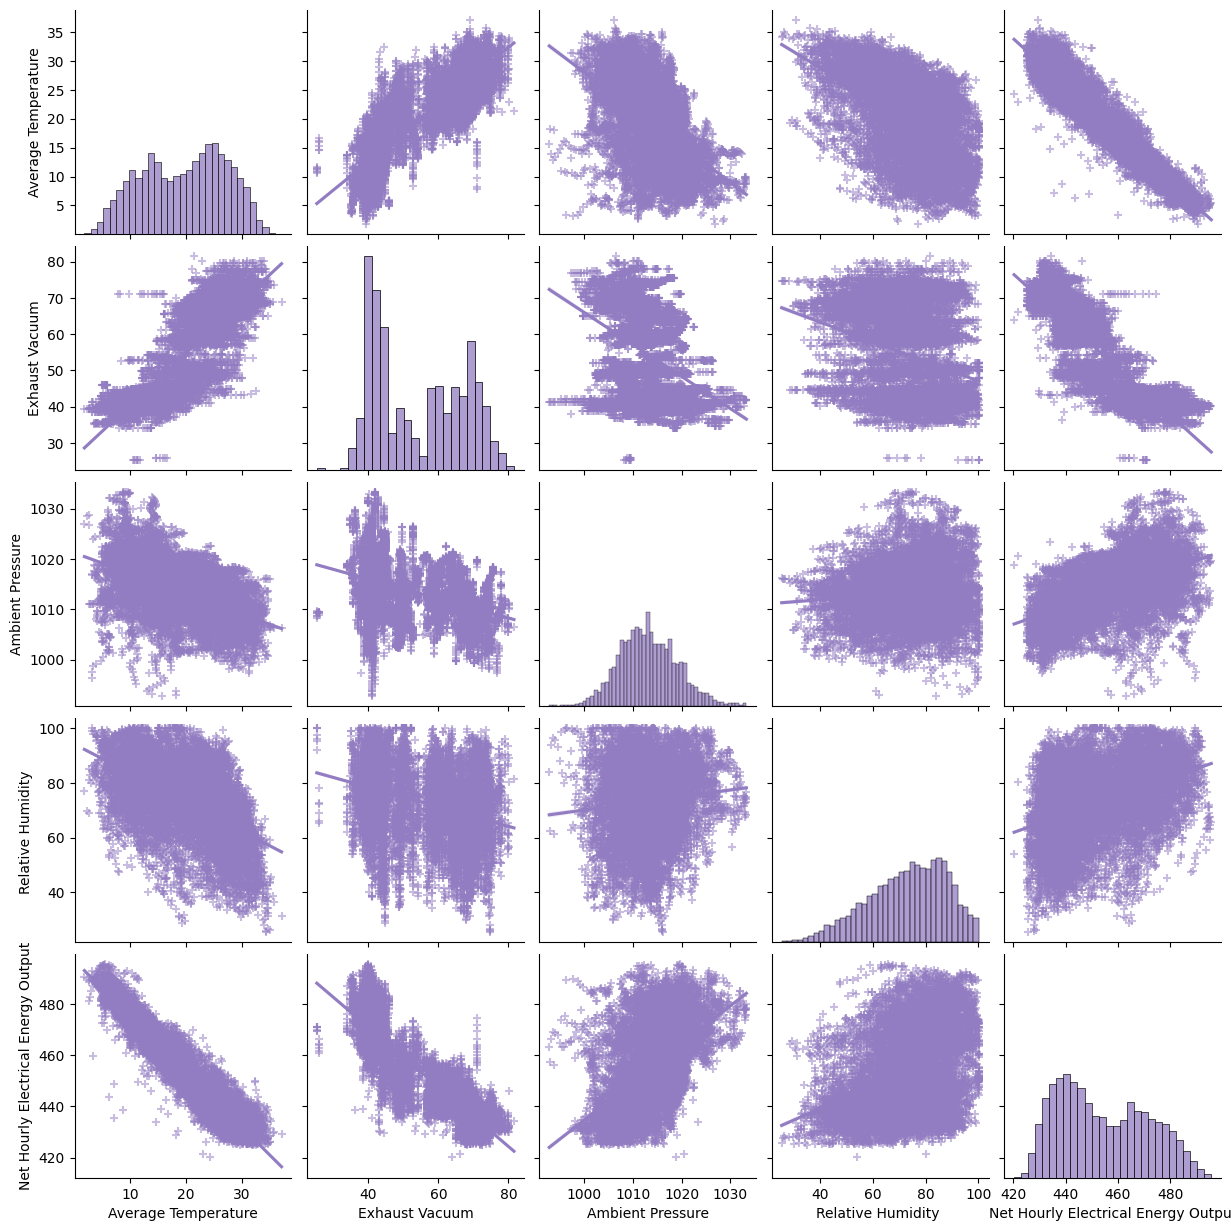

In [47]:
sns.pairplot(dataset,
                 markers="+",
                 kind='reg',
                 diag_kind="auto",
                 plot_kws={'line_kws':{'color':'#937DC2'},
                           'scatter_kws': {'alpha': 0.5,
                                           'color': '#937DC2'}},

                 diag_kws= {'color': '#937DC2'})

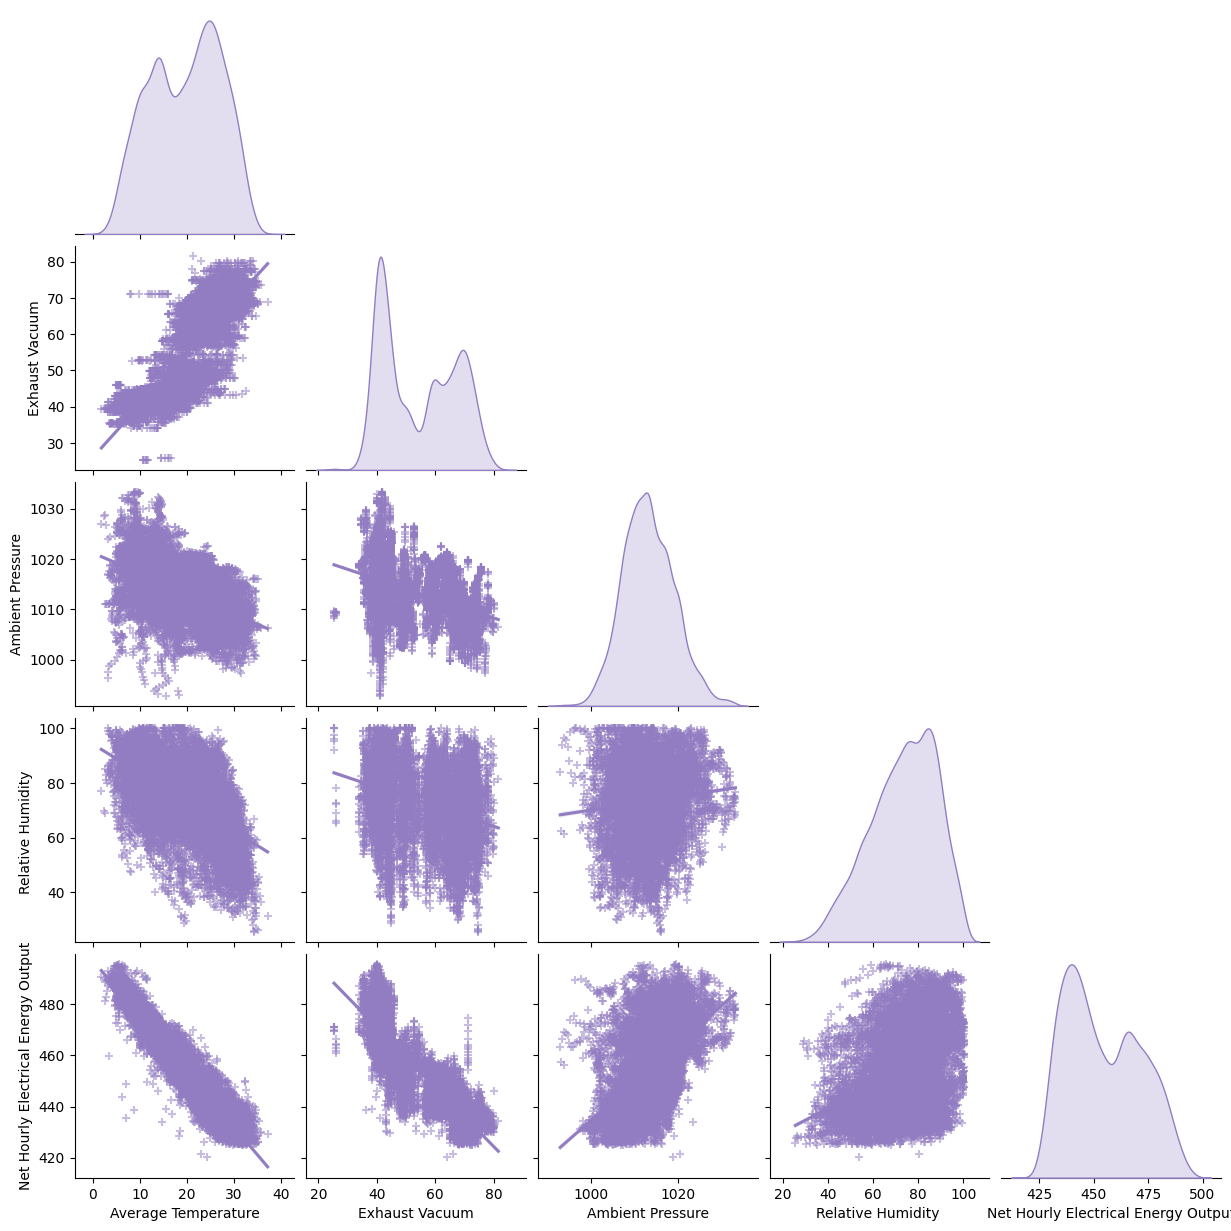

In [48]:
sns.pairplot(dataset,
                 markers="+",
                 kind='reg',
                 diag_kind="kde",
                 plot_kws={'line_kws':{'color':'#937DC2'},
                           'scatter_kws': {'alpha': 0.5,
                                           'color': '#937DC2'}},
               corner=True,
                 diag_kws= {'color': '#937DC2'})

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Membangun arsitektur ANN baseline sebagai metode acuan

In [50]:
ann = tf.keras.models.Sequential()

In [51]:
#Adding the input layer and the first hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
#Adding the second hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
#Adding the output layer
ann.add(tf.keras.layers.Dense(units=1))


In [52]:
#Training the ANN
ann.compile(optimizer = 'adam', loss = 'mean_squared_error')
#Training the ANN model on the Training set
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 963906.5625
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4455.7158
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 583.1132
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 568.8635
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 554.4797
Epoch 6/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 541.0089
Epoch 7/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 509.9164
Epoch 8/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 489.8810
Epoch 9/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 468.0612
Epoch 10/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 441.5176
Epoch 11/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 416.9933
Epoch 12/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 383.0602
Epoch 13/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 352.5288
Epoch 14/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 316.1615
Epoch 15/10

In [53]:
y_pred = ann.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[431.28 431.23]
 [462.34 460.01]
 [465.85 461.14]
 ...
 [473.09 473.26]
 [439.82 438.  ]
 [459.06 463.28]]


### menghitung RMSE,MSE, MAE, dan R²

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Hitung MAE (Rata-rata selisih absolut antara prediksi dan label)
mae = mean_absolute_error(y_test, y_pred)

# Hitung MSE (rata-rata dari kuadrat selisih antara nilai aktual dan nilai prediksi)
mse = mean_squared_error(y_test, y_pred)

# Hitung RMSE (Akar dari rata-rata error kuadrat)
rmse = np.sqrt(mse)

# Hitung R² (Koefisien determinasi)
r2 = r2_score(y_test, y_pred)

# Tampilkan hasil
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MAE  : 3.9390
MSE  : 24.5564
RMSE : 4.9554
R²   : 0.9160


MAE  : 3.9390
MSE  : 24.5564
RMSE : 4.9554
R²   : 0.9160


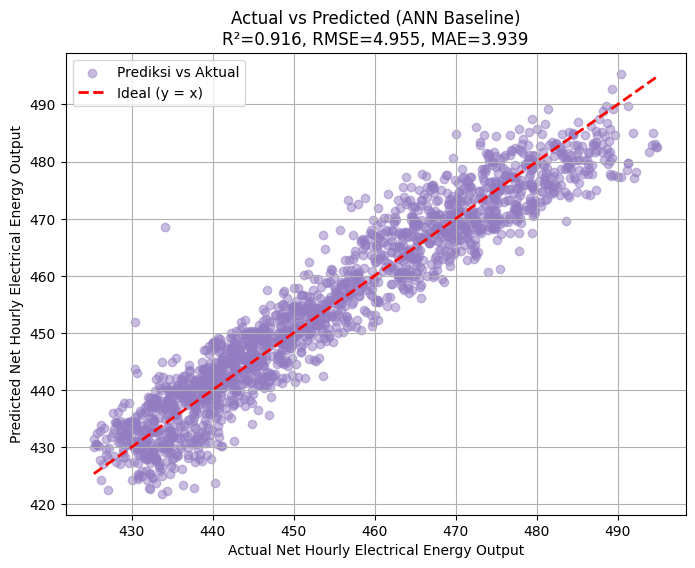

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Hitung metrik
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Tampilkan metrik
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Plot real vs prediksi
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="#937DC2", label="Prediksi vs Aktual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label="Ideal (y = x)")

# Label dan judul
plt.xlabel("Actual Net Hourly Electrical Energy Output")
plt.ylabel("Predicted Net Hourly Electrical Energy Output")
plt.title(f"Actual vs Predicted (ANN Baseline)\nR²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")
plt.legend()
plt.grid(True)
plt.show()


### Tambahan arsitektur kode untuk membandingkan Prediksi menggunakan ANN pada setiap sheet

In [56]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from google.colab import drive

# Mount drive
drive.mount("/content/drive")

# File path
file_path = "/content/drive/MyDrive/Folds5x2_pp.xlsx"
xls = pd.ExcelFile(file_path)
sheets = xls.sheet_names
print("Sheets ditemukan:", sheets)

# Simpan hasil setiap sheet
results = []

# Loop untuk memproses semua sheet dalam file Excel
for sheet in sheets:
    print(f"🔹 Processing sheet: {sheet}")

    # Baca data
    data = pd.read_excel(file_path, sheet_name=sheet)
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values

    # Split data jadi train dan test (80/20)
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Build ANN model
    ann = tf.keras.models.Sequential([
        tf.keras.layers.Dense(6, activation='relu', input_shape=(X.shape[1],)),
        tf.keras.layers.Dense(6, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    ann.compile(optimizer='adam', loss='mean_squared_error')

    # Train model
    ann.fit(X_train, y_train, batch_size=32, epochs=100, verbose=0)

    # Predict
    y_pred = ann.predict(X_test).flatten()

    # Hitung metrik
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ {sheet} - MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

    results.append({
        'Sheet': sheet,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

# Ringkasan hasil
results_df = pd.DataFrame(results)
print("\n📊 Ringkasan hasil:")
print(results_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sheets ditemukan: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4', 'Sheet5']
🔹 Processing sheet: Sheet1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Sheet1 - MAE: 4.1128, MSE: 26.5427, RMSE: 5.1520, R²: 0.9081
🔹 Processing sheet: Sheet2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Sheet2 - MAE: 3.9901, MSE: 25.9603, RMSE: 5.0951, R²: 0.9120
🔹 Processing sheet: Sheet3


...

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Sheet3 - MAE: 4.0899, MSE: 26.6675, RMSE: 5.1641, R²: 0.9079
🔹 Processing sheet: Sheet4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Sheet4 - MAE: 4.2036, MSE: 28.2664, RMSE: 5.3166, R²: 0.8998
🔹 Processing sheet: Sheet5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Sheet5 - MAE: 3.9590, MSE: 24.6592, RMSE: 4.9658, R²: 0.9181

📊 Ringkasan hasil:
    Sheet       MAE        MSE      RMSE        R2
0  Sheet1  4.112791  26.542684  5.151959  0.908080
1  Sheet2  3.990116  25.960271  5.095122  0.912013
2  Sheet3  4.089918  26.667495  5.164058  0.907902
3  Sheet4  4.203643  28.266443  5.316620  0.899778
4  Sheet5  3.959014  24.659213  4.965804  0.918074


### Validasi di seluruh dataset


✅ Best performance: Sheet5 with R² = 0.9181


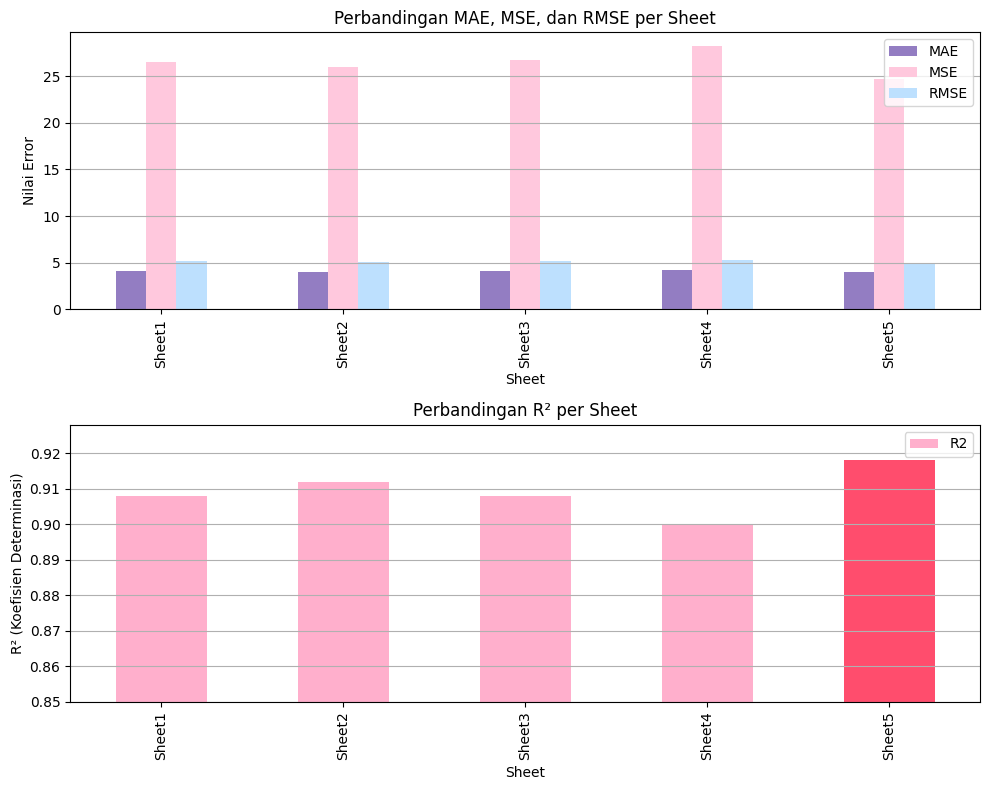

In [57]:
# Tentukan sheet dengan R² terbaik
# Karena memberi indikasi kebaikan fit model terhadap data (tanpa terpengaruh skala satuan).
best_sheet = results_df.loc[results_df['R2'].idxmax()]
print(f"\n✅ Best performance: {best_sheet['Sheet']} with R² = {best_sheet['R2']:.4f}")

import matplotlib.pyplot as plt

# Buat plot untuk MAE, MSE, RMSE, dan R²
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Plot MAE, MSE, RMSE
results_df.plot(
    x='Sheet',
    y=['MAE', 'MSE', 'RMSE'],
    kind='bar',
    ax=ax[0],
    color=['#937DC2', '#FFC8DD', '#BDE0FE']
)
ax[0].set_title('Perbandingan MAE, MSE, dan RMSE per Sheet')
ax[0].set_ylabel('Nilai Error')
ax[0].grid(axis='y')

# Plot R² dengan y-axis mulai dari 0.85 agar perbedaan terlihat jelas
results_df.plot(
    x='Sheet',
    y='R2',
    kind='bar',
    ax=ax[1],
    color=['#FFAFCC' if s != best_sheet['Sheet'] else '#FF4D6D' for s in results_df['Sheet']]  # Highlight best sheet
)
ax[1].set_title('Perbandingan R² per Sheet')
ax[1].set_ylabel('R² (Koefisien Determinasi)')
ax[1].set_ylim(0.85, results_df['R2'].max() + 0.01)  # Fokus ke rentang nilai tinggi
ax[1].grid(axis='y')

plt.tight_layout()
plt.show()
